In [18]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import copy
import sklearn.metrics as metrics

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [19]:
df=pd.read_csv(r'C:\Users\User\Downloads\USA_Housing (1).csv') 
 

In [20]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [21]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [22]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled = scaler.fit_transform(df.select_dtypes(include=['float64', 'int64']))

df_scaled = pd.DataFrame(scaled, columns=df.select_dtypes(include=['float64', 'int64']).columns)

In [23]:
df = df_scaled

In [24]:
X=df[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population']]
y=df['Price']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [26]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [27]:
y_pred=model.predict(X_test)

In [28]:
mse=metrics.mean_squared_error(y_test,y_pred)
r2=metrics.r2_score(y_test,y_pred)

In [29]:
print(mse)
print(r2)

0.0016730980432775192
0.9146818498754016


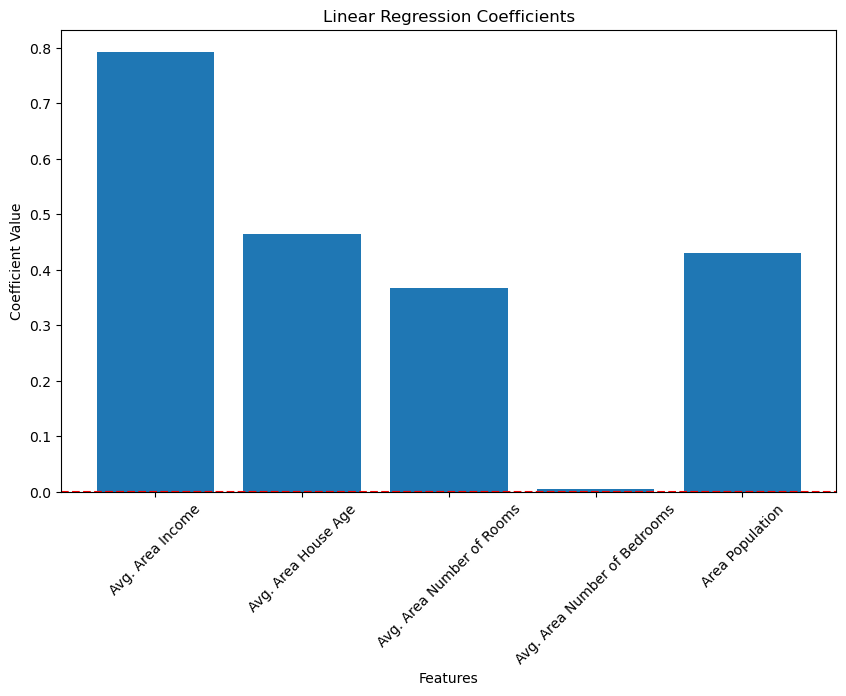

In [30]:
import matplotlib.pyplot as plt

# Koefisentlər DataFrame formasına salaq
import pandas as pd
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

# Çəkiliş
plt.figure(figsize=(10,6))
plt.bar(coef_df["Feature"], coef_df["Coefficient"])
plt.axhline(0, color='red', linestyle='--')  # 0 xətti
plt.xticks(rotation=45)
plt.title("Linear Regression Coefficients")
plt.ylabel("Coefficient Value")
plt.xlabel("Features")
plt.show()